In [ ]:
import pandas as pd, numpy as np, joblib
from sklearn.model_selection import (
    train_test_split, KFold, cross_validate,
    GridSearchCV)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso)
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor)
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error, r2_score)

In [2]:
from google.cloud import bigquery
from dotenv import load_dotenv
import datetime

# 1. Authentification locale (remplace auth.authenticate_user() de Colab)
# Cela va chercher automatiquement la variable GOOGLE_APPLICATION_CREDENTIALS dans votre fichier .env
load_dotenv()

PROJET = "les-fourcasters"
DATASET = "dbt_dev_marts"

# 2. Initialisation du client
client = bigquery.Client(project=PROJET)
print("Client prêt sur", client.project)

# 3. Récupération des données dans un DataFrame pandas
annee_en_cours=datetime.date.today().year # Année à prédire

canicules_features = client.query(f"SELECT * FROM `{PROJET}.{DATASET}.canicule_features`").to_dataframe()
canicules_features=canicules_features[canicules_features['annee_reference_canicule']<annee_en_cours]
print(f"""✅ Données chargées avec succès ! Dimensions du dataset : {canicules_features.shape}.
Années non pris en compte : {annee_en_cours} et au delà""")

Client prêt sur les-fourcasters
✅ Données chargées avec succès ! Dimensions du dataset : (2112, 16).
Années non pris en compte : 2026 et au delà


In [3]:
canicules_features.sample(5)

,code_departement,annee_reference_canicule,t_moy_automne,precip_automne,t_moy_hiver,precip_hiver,t_moy_printemps,precip_printemps,humidite_printemps,part_jours_secs_printemps,t_max_mai,part_jours_chauds_mai,nb_jour_canicules,evenement_caniculaire,population_exposee,severite
885,13,2012,16.910549,2.876484,6.250110,0.345934,14.264348,1.759130,63.913043,0.765217,22.373548,0.232258,0.0,False,0.0,0.0
1001,01,2014,11.599121,4.907692,4.193556,4.750222,10.980870,2.271957,71.882609,0.671739,17.516129,0.025806,0.0,False,0.0,0.0
2131,90,2025,11.236264,4.040659,3.032222,3.782222,10.882609,2.194565,72.576087,0.652174,18.454839,0.096774,8.0,True,138419.0,16.2
2102,36,2006,13.429011,1.652967,3.097556,1.849556,10.518478,2.429565,75.780435,0.610870,18.628387,0.032258,8.0,True,232959.0,8.8
397,05,2006,8.565934,1.727473,-4.311111,2.371852,5.123188,3.114130,74.485507,0.583333,14.323656,0.000000,0.0,False,0.0,0.0


In [4]:
CIBLE   = 'evenement_caniculaire'
A_JETER = [
    'nb_jour_canicules', 
    'severite',
    'population_exposee', 
    ]

print(canicules_features.shape, "| doublons :", canicules_features.duplicated().sum())
print(canicules_features.isna().mean().mul(100).round(1)[lambda s: s > 0])
print(canicules_features.describe())     # cherche les min/max absurdes
print(canicules_features.corr(numeric_only=True)[CIBLE].sort_values())

(2112, 16) | doublons : 0
Series([], dtype: float64)
       annee_reference_canicule  t_moy_automne  precip_automne  t_moy_hiver  \
count                    2112.0    2112.000000     2112.000000  2112.000000   
mean                     2014.5      13.120487        2.565164     5.035569   
std                    6.345791       1.807783        1.006444     2.133831   
min                      2004.0       6.645421        0.448132    -4.311111   
25%                      2009.0      11.953571        1.822985     3.668704   
50%                      2014.5      13.007875        2.435385     5.159421   
75%                      2020.0      14.256941        3.127473     6.542343   
max                      2025.0      19.224908        8.270696    11.246886   

       precip_hiver  t_moy_printemps  precip_printemps  humidite_printemps  \
count   2112.000000      2112.000000       2112.000000         2112.000000   
mean       2.531965        11.142754          2.462782           74.075501   
s

In [5]:
X = canicules_features.drop(columns=[CIBLE] + A_JETER)
y = canicules_features[CIBLE]

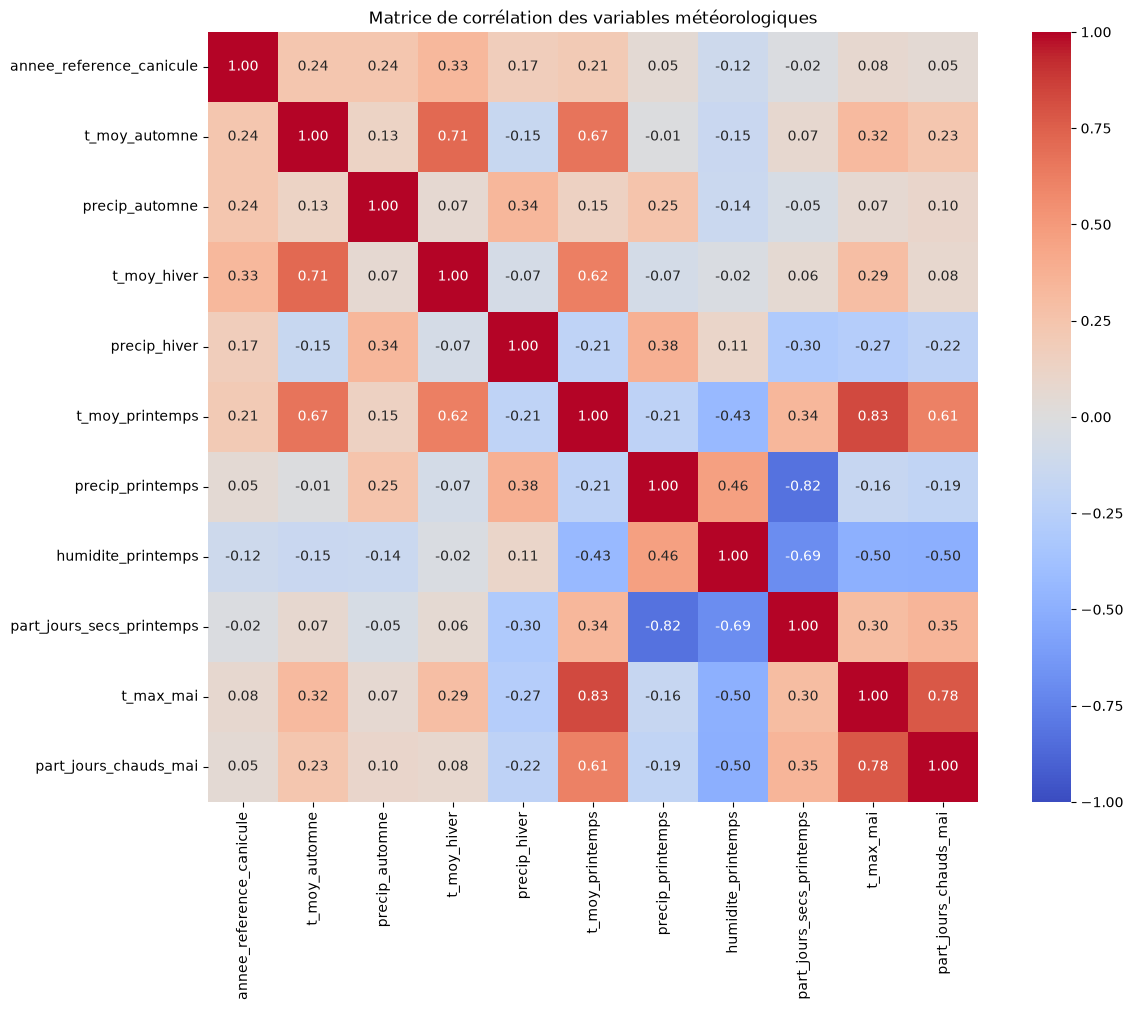

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul de la matrice sur vos features d'entraînement (X)
matrice_corr = X.corr(numeric_only=True)

# 2. Configuration visuelle de la carte de chaleur
plt.figure(figsize=(14, 10))
sns.heatmap(
    matrice_corr, 
    annot=True,        # Affiche les scores de corrélation
    fmt=".2f",         # Limite à 2 décimales pour la lisibilité
    cmap="coolwarm",   # Dégradé : rouge (corrélation positive), bleu (négative)
    vmin=-1, vmax=1,   # Borne l'échelle mathématique
    center=0,
    square=True
)
plt.title("Matrice de corrélation des variables météorologiques")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# ---- 5. Preparation : une branche par type ----
num = X.select_dtypes(include=np.number).columns.tolist()
cat = X.select_dtypes(exclude=np.number).columns.tolist()

branche_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())])
branche_cat = Pipeline([
    ("imputer", 
    SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

prep = ColumnTransformer([("num", branche_num, num), ("cat", branche_cat, cat)])

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline

# ---- 6. Comparer en validation croisée -------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rs = dict(random_state=42)

modeles = {
    "Dummy":  DummyClassifier(strategy="prior"),
    "LogReg": LogisticRegression(max_iter=2000),
    "Foret":  RandomForestClassifier(n_jobs=-1, min_samples_leaf=10, **rs),
    "HistGB": HistGradientBoostingClassifier(**rs),
}

print(f"{'Modèle':<10} | {'AUC test':<10} | {'Std AUC':<10} | {'AUC train':<10}")
print("-" * 50)

for nom, m in modeles.items():
    tube = Pipeline([("prep", prep), ("modele", m)])
    r = cross_validate(tube, X_train, y_train, cv=cv,
                       scoring="roc_auc", return_train_score=True)
    print(f"{nom:<10} | {r['test_score'].mean():<10.3f} | "
          f"{r['test_score'].std():<10.3f} | {r['train_score'].mean():<10.3f}")

Modèle     | AUC test   | Std AUC    | AUC train 
--------------------------------------------------
Dummy      | 0.500      | 0.000      | 0.500     
LogReg     | 0.821      | 0.020      | 0.864     
Foret      | 0.824      | 0.027      | 0.880     
HistGB     | 0.876      | 0.017      | 1.000     


In [12]:
modele = HistGradientBoostingClassifier(**rs)
tube = Pipeline([("prep", prep), ("modele", modele)])
grille = {
    "modele__learning_rate": [0.05, 0.1],
    "modele__max_depth": [2, 3],
    "modele__min_samples_leaf": [50, 100],
    "prep__num__imputer__strategy": ["median", "mean"],
}
gs = GridSearchCV(tube, grille, cv=cv, n_jobs=-1, scoring="roc_auc")
gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modele__learning_rate': [0.05, 0.1], 'modele__max_depth': [2, 3], 'modele__min_samples_leaf': [50, 100], 'prep__num__imputer__strategy': ['median', 'mean']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated scor

In [13]:
# # ---- 7. Régler les hyperparamètres du meilleur modèle --
# modele = LogisticRegression(max_iter=2000)
# tube = Pipeline([("prep", prep), ("modele", modele)])

# grille = {
#     "modele__C": [0.01, 0.1, 1.0, 10.0],   # inverse de la régularisation
#     "prep__num__imputer__strategy": ["median", "mean"],
# }

# gs = GridSearchCV(tube, grille, cv=cv, n_jobs=-1, scoring="roc_auc")
# gs.fit(X_train, y_train)

# print("Meilleurs paramètres :", gs.best_params_)
# print("Meilleure AUC CV :", round(gs.best_score_, 3))

In [14]:
import joblib
import numpy as np
from sklearn.metrics import roc_auc_score, brier_score_loss, confusion_matrix

# ---- 8. Évaluation sur le test ------------
final = gs.best_estimator_
proba = final.predict_proba(X_test)[:, 1]

print(f"AUC test : {roc_auc_score(y_test, proba):.3f}")
print(f"Brier    : {brier_score_loss(y_test, proba):.3f}  (plus bas = mieux)")

seuil = 0.5
pred = (proba >= seuil).astype(int)
print("Matrice de confusion (lignes = réel, colonnes = prédit) :")
print(confusion_matrix(y_test, pred))

# ---- 9. Réentraîner sur TOUTES les données puis sauvegarder ----
X_tout = pd.concat([X_train, X_test])
y_tout = pd.concat([y_train, y_test])
final.fit(X_tout, y_tout)

joblib.dump(final, "modele_canicule_evenement.joblib")
print("Modèle sauvegardé.")

AUC test : 0.893
Brier    : 0.128  (plus bas = mieux)
Matrice de confusion (lignes = réel, colonnes = prédit) :
[[230  34]
 [ 43 116]]
Modèle sauvegardé.
